# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 

## Lab 1
### Running a sample script

In [2]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [4]:
y_pred = model.predict(X_test)  # The predicted score is quite close to the actual score
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [5]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


r_square shows us how well the linear regression model fits the data. If the score is closer to 1, it means 
the model explains the data well and it makes acurate predictions. That is why our predicted score is close to the actual score

C:\Users\tihitinazergaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


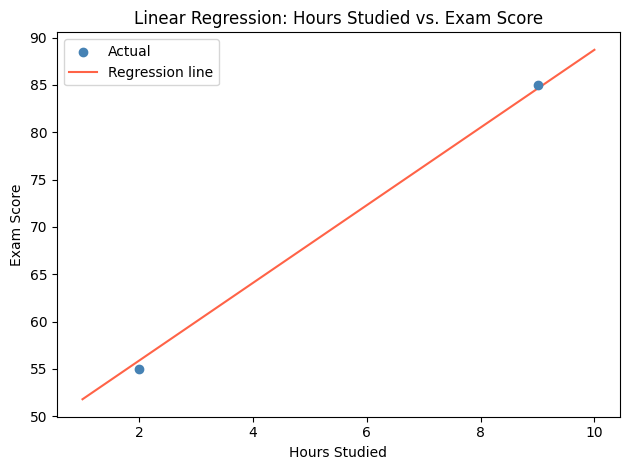

In [6]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
 X['hours_studied'].min(),
 X['hours_studied'].max(),
 100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

The actual data points follow the regression line very closely. At 8 hours studied, the actual data point almost overlaps with the 
regression line. This tells us that the model fits the data well and makes accurate predictions.

## Lab 2
### Building your own model

In [7]:
ad_data = {
 'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
 'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}

df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [37]:
x2 = df_ads[['monthly_ad_spend']]   #  Defining features (X) and target (y)
y2 = df_ads['monthly_revenue']
print(x2.shape)
print(y2.shape)

(20, 1)
(20,)


In [38]:
x2_train, x2_test, y2_train, y2_test = train_test_split(  # Spliting into train and test sets

    x2, y2, test_size=0.2, random_state=42
)

In [39]:
model2 = LinearRegression()      # Creating the model and fit it to training data

model2.fit(x2_train, y2_train)

print('Model trained successfully.')

Model trained successfully.


In [41]:
print(f'Slope: {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')
# for each additional $1 spent on ads, the predicted revenue increases by $1.96.

Slope: 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

In [42]:
y2_pred = model2.predict(x2_test)  # The predicted score is quite close to the actual score
print('Actual Revenue: ', list(y2_test))
print('Predicted Revenue:', list(y2_pred.round(2)))

Actual Revenue:  [4200, 21500, 19400, 5100]
Predicted Revenue: [np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


In [43]:
r_squared = model2.score(x2_test, y2_test)
print(f'R² Revenue: {r_squared:.3f}')

R² Revenue: 0.998


The r_square is close to 1, that tells us the model fits the data very well.
Even though there are small differences the predicted values are close to the actual revenue values.
Since r_square is 0.998, 99.8% of the variation in revenue is explained by ad spend.

### Visualizing the results

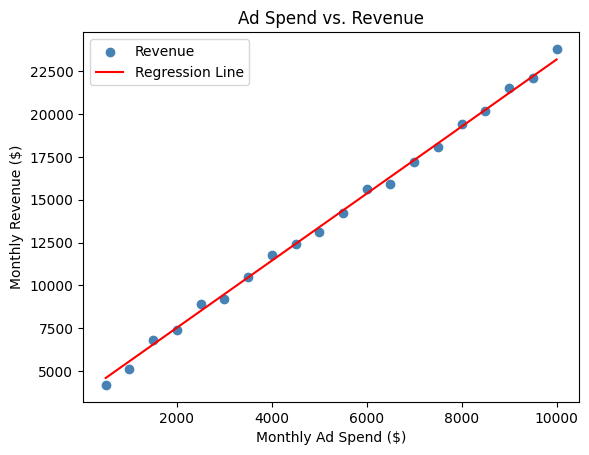

In [44]:
plt.scatter(x2, y2, color='steelblue', label='Revenue')
y_line = model2.predict(x2)
plt.plot(x2, y_line, color='red', label='Regression Line')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.show()

The regression line appear to fit the data well visually.
Yes, this matchs what the R² score told us. The regression line is very close to the data points and overlaps at some points. 

## Bonus
### test_size=.3 and random_state=10

With test_size=.3 and random_state=10, there is a slight difference in the predicted revenue values but the r_square is the same. The slope and intercept also changed slightly. 